# Cyberbullying Detection using Machine Learning  

## MCA Final Year Project  

### Author: Group 1  
### Department: Master of Computer Applications  
### Academic Year: 2025–2026  


Import Required Libraries

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score

Download NLTK Resources

In [9]:
# %%
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Load Dataset

In [10]:
df = pd.read_csv("data/train.csv")

label_columns = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Dataset Shape: (159571, 8)

Missing Values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Exploratory Data Analysis

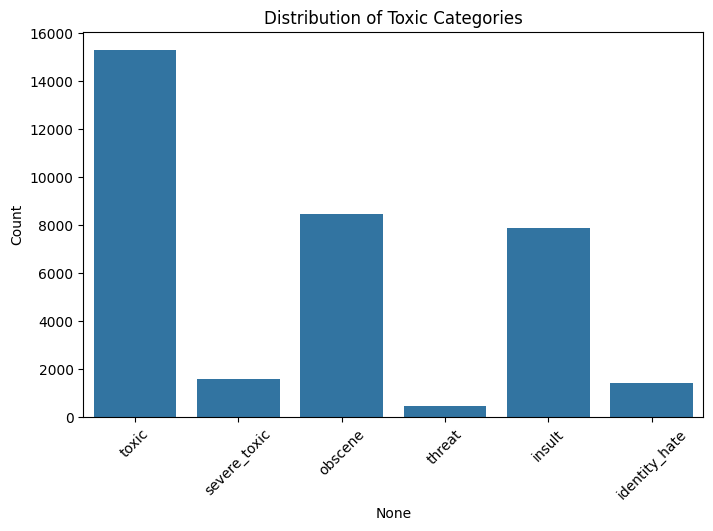

In [11]:
label_counts = df[label_columns].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Toxic Categories")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

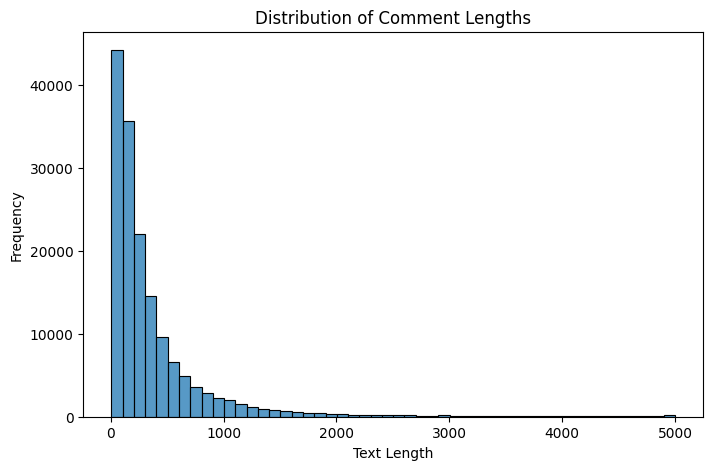

In [12]:
df['text_length'] = df['comment_text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

Text Preprocessing

In [13]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['comment_text'].apply(clean_text)
# df[['comment_text', 'clean_text']].head()
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,text_length,clean_text
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,explanation edits made username hardcore metal...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,aww match background colour seemingly stuck th...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,hey man really trying edit war guy constantly ...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,make real suggestion improvement wondered sect...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,sir hero chance remember page


TF-IDF Feature Engineering

In [14]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df[label_columns]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (159571, 5000)
Target Shape: (159571, 6)


Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (127656, 5000)
Testing Shape: (31915, 5000)


 Multi-Label Model Training & Comparison

In [16]:
# Logistic Regression
log_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, target_names=label_columns))
log_f1 = f1_score(y_test, y_pred_log, average='macro')


===== Logistic Regression =====
               precision    recall  f1-score   support

        toxic       0.91      0.63      0.74      3056
 severe_toxic       0.60      0.26      0.37       321
      obscene       0.91      0.65      0.76      1715
       threat       0.67      0.14      0.22        74
       insult       0.82      0.53      0.65      1614
identity_hate       0.74      0.18      0.29       294

    micro avg       0.88      0.57      0.69      7074
    macro avg       0.77      0.40      0.51      7074
 weighted avg       0.87      0.57      0.68      7074
  samples avg       0.06      0.05      0.05      7074



d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(a

In [17]:
# Naive Bayes
nb_model = OneVsRestClassifier(MultinomialNB())
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("\n===== Naive Bayes =====")
print(classification_report(y_test, y_pred_nb, target_names=label_columns))
nb_f1 = f1_score(y_test, y_pred_nb, average='macro')


===== Naive Bayes =====


d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

               precision    recall  f1-score   support

        toxic       0.92      0.53      0.67      3056
 severe_toxic       0.60      0.18      0.28       321
      obscene       0.90      0.55      0.68      1715
       threat       0.00      0.00      0.00        74
       insult       0.82      0.46      0.59      1614
identity_hate       0.63      0.07      0.13       294

    micro avg       0.88      0.48      0.62      7074
    macro avg       0.65      0.30      0.39      7074
 weighted avg       0.86      0.48      0.61      7074
  samples avg       0.05      0.04      0.04      7074



In [18]:
# Linear SVM
svm_model = OneVsRestClassifier(LinearSVC())
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("\n===== Linear SVM =====")
print(classification_report(y_test, y_pred_svm, target_names=label_columns))
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')


===== Linear SVM =====
               precision    recall  f1-score   support

        toxic       0.88      0.68      0.77      3056
 severe_toxic       0.56      0.26      0.35       321
      obscene       0.89      0.69      0.78      1715
       threat       0.62      0.20      0.31        74
       insult       0.80      0.58      0.67      1614
identity_hate       0.71      0.26      0.38       294

    micro avg       0.85      0.62      0.72      7074
    macro avg       0.74      0.45      0.54      7074
 weighted avg       0.84      0.62      0.71      7074
  samples avg       0.06      0.06      0.06      7074



d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code X\Projects\iter final year\Cyber Bullying\.zenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(a

In [19]:
print("\n===== Model Comparison (Macro F1 Score) =====")
print("Logistic Regression F1:", round(log_f1,4))
print("Naive Bayes F1:", round(nb_f1,4))
print("Linear SVM F1:", round(svm_f1,4))


===== Model Comparison (Macro F1 Score) =====
Logistic Regression F1: 0.5058
Naive Bayes F1: 0.3924
Linear SVM F1: 0.5427


Select and Save Best Model


In [20]:
import os
os.makedirs("models", exist_ok=True)

models = {
    "Logistic Regression": (log_f1, log_model),
    "Naive Bayes": (nb_f1, nb_model),
    "Linear SVM": (svm_f1, svm_model)
}

best_model_name, (best_f1, best_model) = max(
    models.items(),
    key=lambda x: x[1][0]
)

joblib.dump(best_model, "models/best_multilabel_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(label_columns, "models/label_columns.pkl")

print(f"Best model selected: {best_model_name}")
print(f"Macro F1 Score: {round(best_f1,4)}")
print("Model and vectorizer saved successfully.")

Best model selected: Linear SVM
Macro F1 Score: 0.5427
Model and vectorizer saved successfully.


## Prediction Function

## Test

In [21]:
import os
import re
import joblib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ==============================
# Load Resources
# ==============================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "models")

model = joblib.load(os.path.join(MODEL_DIR, "best_multilabel_model.pkl"))
tfidf = joblib.load(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))
label_columns = joblib.load(os.path.join(MODEL_DIR, "label_columns.pkl"))

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


# ==============================
# Text Cleaning Function
# ==============================

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)


# ==============================
# Prediction Function
# ==============================

def predict_multilabel(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    detected_labels = []

    for label, value in zip(label_columns, prediction):
        if value == 1:
            detected_labels.append(label.replace("_", " ").title())

    print("\n========================================")
    print("Input Text:")
    print(text)
    print("----------------------------------------")

    if detected_labels:
        print("⚠ Toxic Categories Detected:")
        for label in detected_labels:
            print(f"  • {label}")
        print(f"\nTotal Categories Detected: {len(detected_labels)}")
    else:
        print("✅ No Toxic Content Detected")

    print("========================================\n")

    return detected_labels


# ==============================
# Run Directly From Terminal
# ==============================

if __name__ == "__main__":
    while True:
        user_input = input("Enter text (or type 'exit'): ")
        if user_input.lower() == "exit":
            break
        predict_multilabel(user_input)

NameError: name '__file__' is not defined

In [ ]:
predict_multilabel("I will fuck you .")

NameError: name 're' is not defined